# Traditional Evaluation Notebook (TF‑IDF + PCA/LPP/NCWP)

This notebook evaluates retrieval performance using traditional TF‑IDF representations
and dimensionality operations (PCA/no‑whitening, LPP‑style top‑k PC removal, NCWP whitening).

Ground‑truth labels: U2, U3 in `labeled_corpus1000.csv`.

Outputs mirror the main evaluation notebook:
- `results_traditional/comparison.csv`
- `results_traditional/map_vs_dim.png`
- `results_traditional/map_vs_dim_<label>.png`
- `results_traditional/metrics_panels_<label>.png`



In [1]:
# Environment and paths
import os
import sys
import torch
import pandas as pd
import numpy as np

# Add project root (../) so local packages can be imported
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print("Project root:", ROOT)
print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())



Project root: /home/workspace/Make_embedding/NCWP
Python: 3.11.10
CUDA available: True


In [2]:
# Parameters
CORPUS = os.path.join(ROOT, "labeled_corpus1000.csv")
OUT_DIR = os.path.join(os.getcwd(), "results_traditional")
DIMS = [2, 4, 8, 16, 32, 64, 128, 256]

os.makedirs(OUT_DIR, exist_ok=True)
print("CORPUS:", CORPUS)
print("OUT_DIR:", OUT_DIR)
print("DIMS:", DIMS)



CORPUS: /home/workspace/Make_embedding/NCWP/labeled_corpus1000.csv
OUT_DIR: /home/workspace/Make_embedding/NCWP/ncwp_eval/results_traditional
DIMS: [2, 4, 8, 16, 32, 64, 128, 256]


In [3]:
# Imports from local packages and sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

from ncwp_eval.code.metrics import build_pos_sets_for_split, metrics_for_pos_sets
from ncwp_eval.code.projector import (
    fit_pca_whitening,
    transform_pca,
    project_out_topk,
    transform_pca_whitening,
    l2_normalize_np,
)
from ncwp_eval.code.graphs import (
    plot_metrics_vs_dim,
    plot_per_label_maps,
    plot_per_label_panels,
)



In [4]:
# Load corpus and build TF-IDF embeddings

df = pd.read_csv(CORPUS)
if "id" not in df.columns or "text" not in df.columns:
    raise ValueError("corpus CSV must have at least 'id' and 'text'")

ids = df["id"].astype(int).tolist()
texts = df["text"].astype(str).tolist()

# Ground-truth columns: prefer U2/U3 if present
GT_COLS = [c for c in ["U2", "U3", "u2", "u3"] if c in df.columns]
if not GT_COLS:
    raise ValueError("No GT columns found. Expected U2/U3 in the corpus CSV.")
print("GT_COLS:", GT_COLS)

# Build positive sets
pos_sets = {col: build_pos_sets_for_split(df, ids, col) for col in GT_COLS}

# TF-IDF vectorization (row-normalized)
vectorizer = TfidfVectorizer(lowercase=True)
X = vectorizer.fit_transform(texts)  # sparse [N, V]
X = sk_normalize(X, norm="l2")
E = X.toarray().astype(np.float32)
E = l2_normalize_np(E)  # safe normalization
base_dim = E.shape[1]
print("TF-IDF base_dim:", base_dim)

# Fit PCA/whitening once
mu, comps, scales = fit_pca_whitening(E, n_components=min(base_dim, max(DIMS)))



GT_COLS: ['U2', 'U3']
TF-IDF base_dim: 175


In [5]:
# Run evaluation: Base / PCA / LPP / NCWP

rows = []
dims = [d for d in DIMS if d <= min(256, base_dim)]

# Base (no projection)
base_row = {"method": "Base", "base_dim": base_dim, "away_dim": base_dim}
for col in GT_COLS:
    m = metrics_for_pos_sets(E, pos_sets[col], ks=(1, 5, 10))
    for mname, mval in m.items():
        base_row[f"{col}_{mname}"] = mval
rows.append(base_row)

# PCA (no whitening)
for k in dims:
    Ep = transform_pca(E, mu, comps, k)
    row = {"method": "PCA", "base_dim": base_dim, "away_dim": k}
    for col in GT_COLS:
        m = metrics_for_pos_sets(Ep, pos_sets[col], ks=(1, 5, 10))
        for mname, mval in m.items():
            row[f"{col}_{mname}"] = mval
    rows.append(row)

# LPP (project out top-k PCs)
for k in dims:
    El = project_out_topk(E, mu, comps, k)
    row = {"method": "LPP", "base_dim": base_dim, "away_dim": k}
    for col in GT_COLS:
        m = metrics_for_pos_sets(El, pos_sets[col], ks=(1, 5, 10))
        for mname, mval in m.items():
            row[f"{col}_{mname}"] = mval
    rows.append(row)

# NCWP (PCA-whitening)
for k in dims:
    Ek = transform_pca_whitening(E, mu, comps, scales, k)
    row = {"method": "NCWP", "base_dim": base_dim, "away_dim": k}
    for col in GT_COLS:
        m = metrics_for_pos_sets(Ek, pos_sets[col], ks=(1, 5, 10))
        for mname, mval in m.items():
            row[f"{col}_{mname}"] = mval
    rows.append(row)

res = pd.DataFrame(rows)
print("Rows:", len(res))
res.head()



Rows: 22


,method,base_dim,away_dim,U2_mAP,U2_nDCG@maxK,U3_mAP,U3_nDCG@maxK
0,Base,175,175,0.805357,0.844859,0.738578,0.801477
1,PCA,175,2,0.086151,0.086513,0.068863,0.072458
2,PCA,175,4,0.228025,0.289922,0.179634,0.229658
3,PCA,175,8,0.365319,0.454753,0.270871,0.339296
4,PCA,175,16,0.478156,0.545969,0.339014,0.397708


Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results_traditional/comparison.csv
Saved plot: /home/workspace/Make_embedding/NCWP/ncwp_eval/results_traditional/map_vs_dim.png


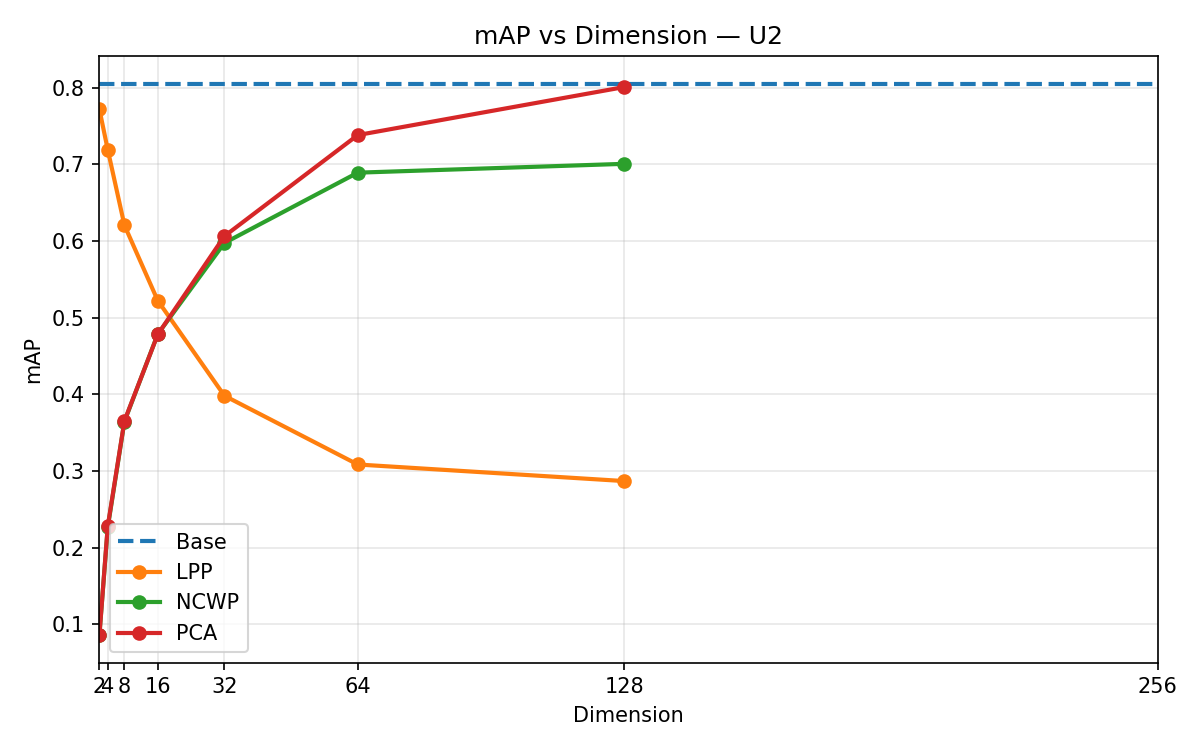

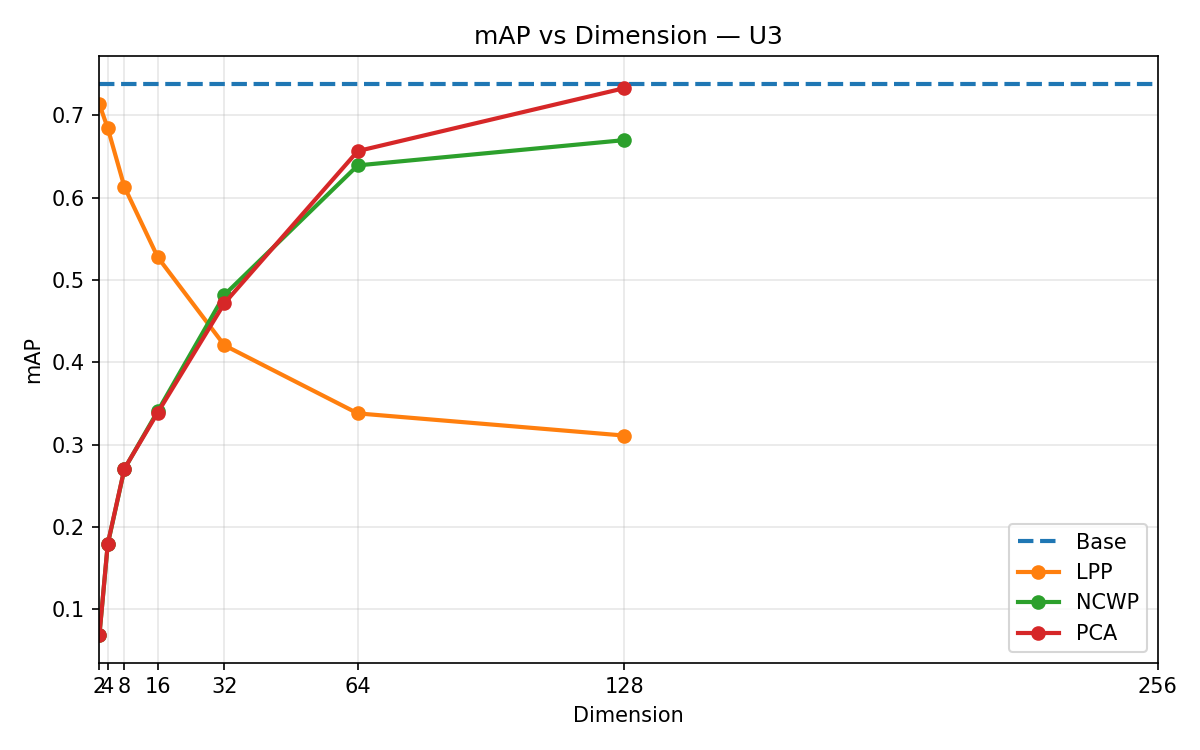

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results_traditional/metrics_panels_U2.png


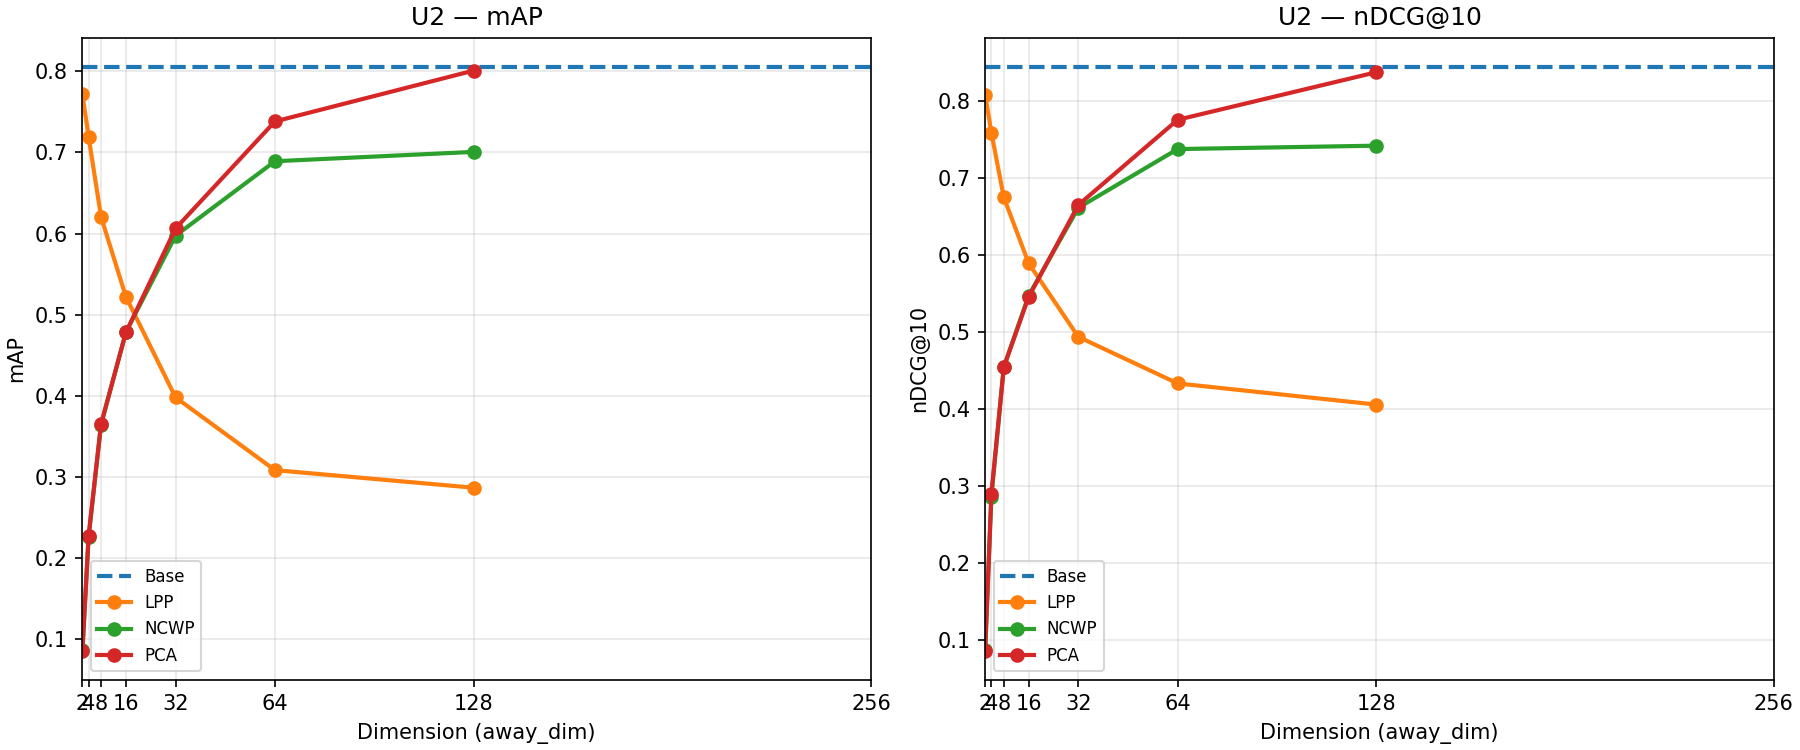

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results_traditional/metrics_panels_U3.png


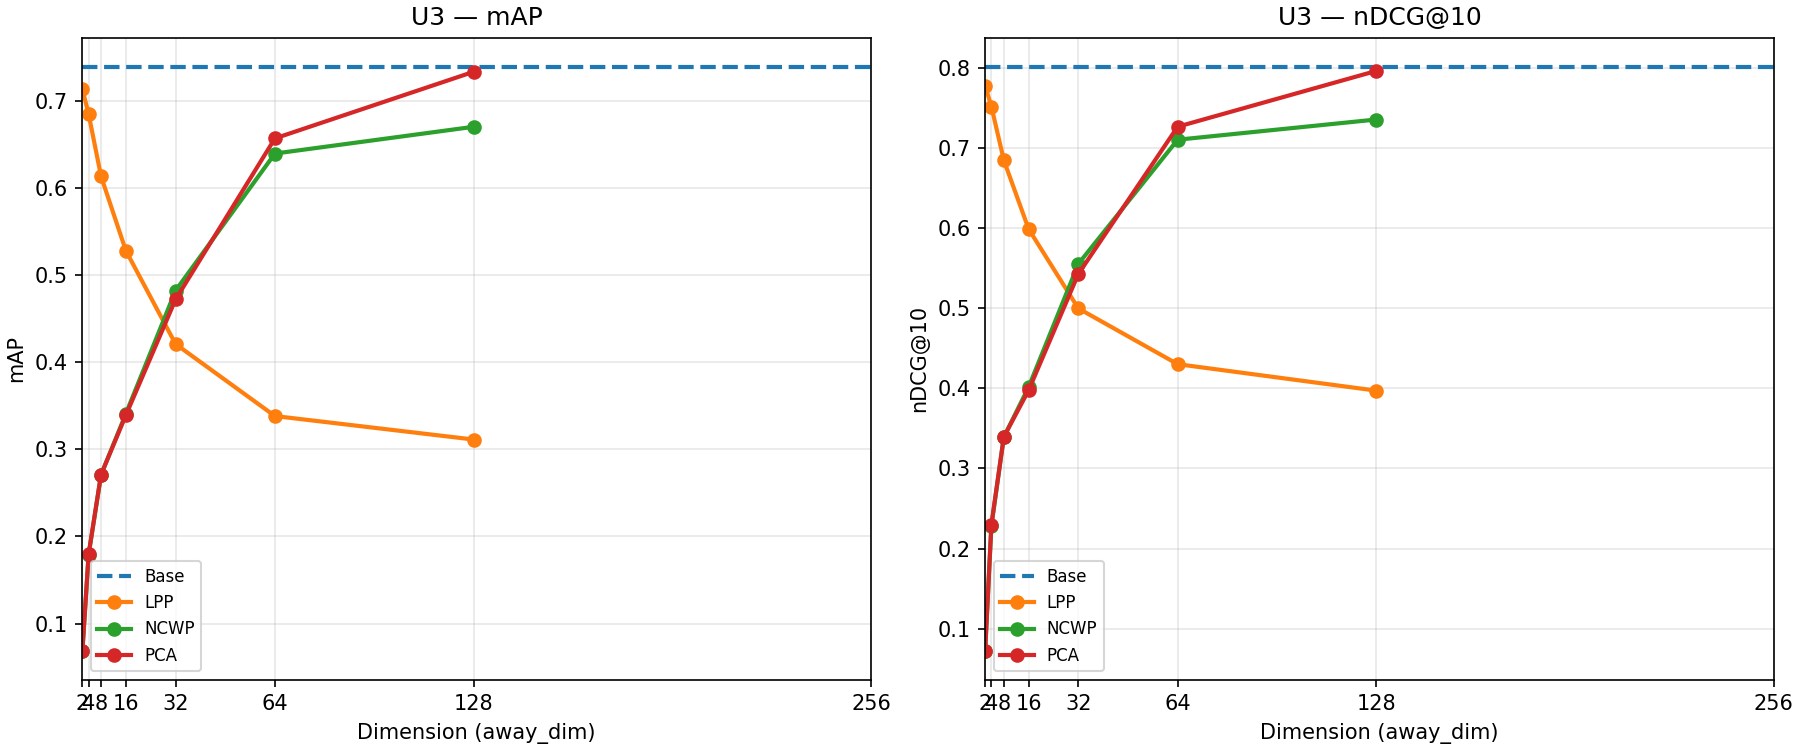

In [6]:
# Save comparison CSV
out_csv = os.path.join(OUT_DIR, "comparison.csv")
res.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Plotting
metrics = []
for col in GT_COLS:
    key = f"{col}_mAP"
    if key in res.columns:
        metrics.append((key, f"{col} mAP"))

plot_path = os.path.join(OUT_DIR, "map_vs_dim.png")
if metrics:
    plot_metrics_vs_dim(res, metrics, "mAP vs Dimension — Base vs PCA vs LPP vs NCWP (traditional)", plot_path)
    print("Saved plot:", plot_path)
else:
    print("No GT columns found for plotting.")

# Per-label plots
from IPython.display import Image, display
labels = [m[0].replace("_mAP", "") for m in metrics]

# Per-label mAP
plot_per_label_maps(res, labels, OUT_DIR, prefix="map_vs_dim")
for lab in labels:
    safe = lab.replace("/", "_")
    map_path = os.path.join(OUT_DIR, f"map_vs_dim_{safe}.png")
    if os.path.exists(map_path):
        display(Image(map_path))

# Per-label panels (mAP/nDCG@maxK)
for lab in labels:
    panel_path = os.path.join(OUT_DIR, f"metrics_panels_{lab.replace('/', '_')}.png")
    plot_per_label_panels(res, lab, panel_path)
    print("Saved:", panel_path)
    if os.path.exists(panel_path):
        display(Image(panel_path))

